In [1]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
 # dataset1= breast cancer 
data = load_breast_cancer()
df1 = pd.DataFrame(data.data, columns=data.feature_names)
df1['target'] = data.target
df1.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
from ucimlrepo import fetch_ucirepo                                         #dataset2= heart disease
heart_disease = fetch_ucirepo(id=45) 

X = heart_disease.data.features
y = heart_disease.data.targets
df2 = pd.concat([X, y], axis=1)
df2

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [4]:
df3=pd.read_csv("diabetes.csv")              #dataset3= diabetes
df3

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
for i, df in enumerate([df1, df2, df3], start=1):
    print(f"Dataset {i}")
    print(df.shape)
    print(df.info())

Dataset 1
(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smooth

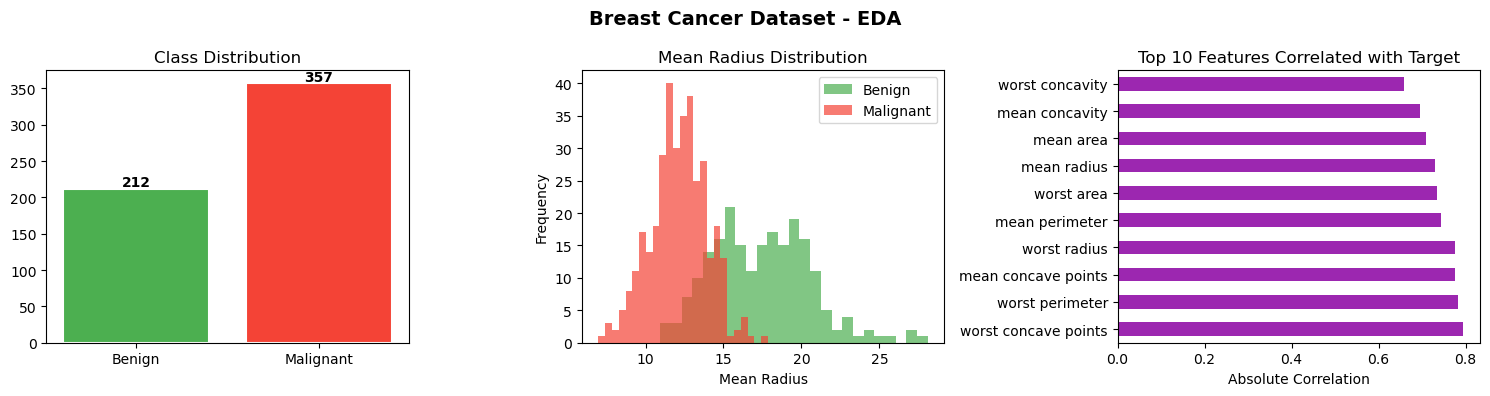


📊 Basic Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


In [6]:
# ─── EDA: Breast Cancer ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Breast Cancer Dataset - EDA', fontsize=14, fontweight='bold')

counts = df1['target'].value_counts()
bars = axes[0].bar(['Benign', 'Malignant'], [counts[0], counts[1]],
                   color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution')
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold')

df1[df1['target']==0]['mean radius'].plot(kind='hist', ax=axes[1],
    alpha=0.7, color='#4CAF50', label='Benign', bins=25)
df1[df1['target']==1]['mean radius'].plot(kind='hist', ax=axes[1],
    alpha=0.7, color='#F44336', label='Malignant', bins=25)
axes[1].set_title('Mean Radius Distribution')
axes[1].set_xlabel('Mean Radius')
axes[1].legend()

# 3. Top feature correlations with target
corr_with_target = df1.corr()['target'].drop('target').abs().sort_values(ascending=False)[:10]
corr_with_target.plot(kind='barh', ax=axes[2], color='#9C27B0')
axes[2].set_title('Top 10 Features Correlated with Target')
axes[2].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()
print("\n📊 Basic Statistics:")
df1.describe().round(2)

In [7]:
df2['num'] = df2['num'].apply(lambda x: 0 if x == 0 else 1)

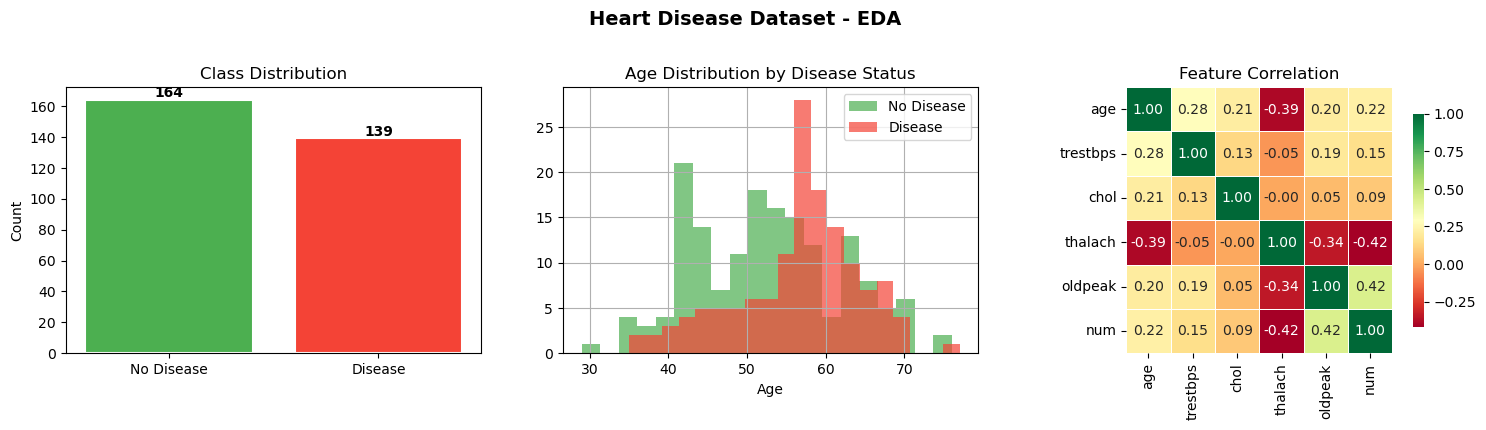


📊 Basic Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [8]:
# ─── EDA: Heart Disease ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Heart Disease Dataset - EDA', fontsize=14, fontweight='bold', y=1.02)

# 1. Class Distribution
counts = df2['num'].value_counts()
axes[0].bar(['No Disease', 'Disease'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# 2. Age Distribution by Disease
df2[df2['num']==0]['age'].hist(ax=axes[1], alpha=0.7, color='#4CAF50', label='No Disease', bins=20)
df2[df2['num']==1]['age'].hist(ax=axes[1], alpha=0.7, color='#F44336', label='Disease', bins=20)
axes[1].set_title('Age Distribution by Disease Status')
axes[1].set_xlabel('Age')
axes[1].legend()

# 3. Correlation Heatmap (key features)
corr_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'num']
corr = df2[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[2],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()
print("\n📊 Basic Statistics:")
df2.describe().round(2)

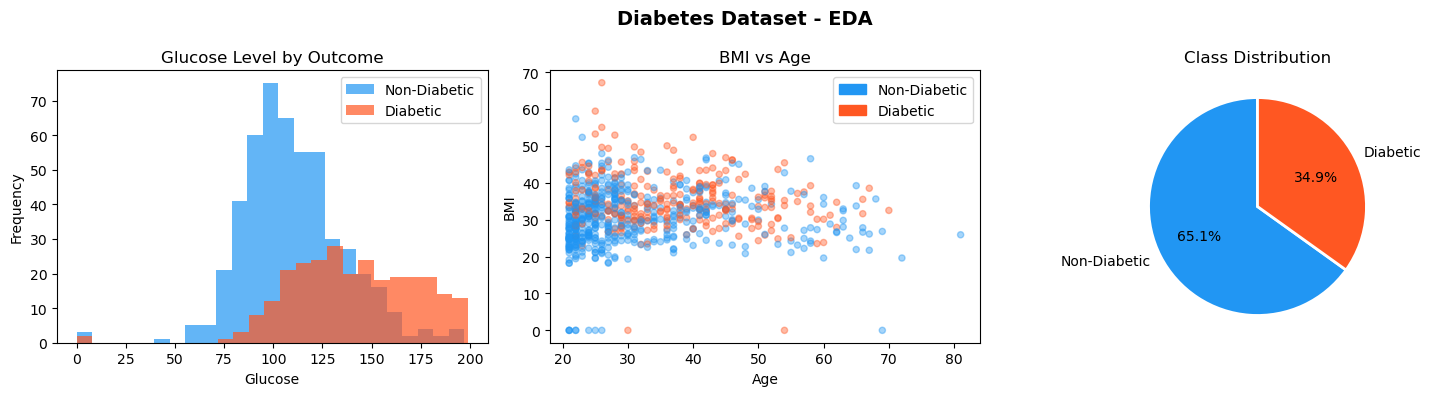


📊 Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [9]:
# ─── EDA: Diabetes ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Diabetes Dataset - EDA', fontsize=14, fontweight='bold')

# 1. Glucose Distribution
df3[df3['Outcome']==0]['Glucose'].plot(kind='hist', ax=axes[0],
    alpha=0.7, color='#2196F3', label='Non-Diabetic', bins=25)
df3[df3['Outcome']==1]['Glucose'].plot(kind='hist', ax=axes[0],
    alpha=0.7, color='#FF5722', label='Diabetic', bins=25)
axes[0].set_title('Glucose Level by Outcome')
axes[0].set_xlabel('Glucose')
axes[0].legend()

# 2. BMI vs Age scatter
scatter_colors = ['#2196F3' if o==0 else '#FF5722' for o in df3['Outcome']]
axes[1].scatter(df3['Age'], df3['BMI'], c=scatter_colors, alpha=0.4, s=20)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('BMI')
axes[1].set_title('BMI vs Age')
p1 = mpatches.Patch(color='#2196F3', label='Non-Diabetic')
p2 = mpatches.Patch(color='#FF5722', label='Diabetic')
axes[1].legend(handles=[p1, p2])

# 3. Outcome distribution
counts = df3['Outcome'].value_counts()
axes[2].pie(counts.values, labels=['Non-Diabetic', 'Diabetic'],
            colors=['#2196F3', '#FF5722'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Class Distribution')

plt.tight_layout()
plt.show()
print("\n📊 Basic Statistics:")
df3.describe().round(2)

In [10]:
print(df1.isnull().sum())
print(df2.isnull().sum())
print(df3.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
rest

In [11]:
print(df2['ca'].unique())
print(df2['thal'].unique())

[ 0.  3.  2.  1. nan]
[ 6.  3.  7. nan]


In [12]:
print(df2['ca'].mode())
print(df2['thal'].mode())

0    0.0
Name: ca, dtype: float64
0    3.0
Name: thal, dtype: float64


In [13]:
df2['ca'] = df2['ca'].fillna(0.0)
df2['thal'] = df2['thal'].fillna(3.0)

In [14]:
df2.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [15]:
print(df1.duplicated().sum())
print(df2.duplicated().sum())
print(df3.duplicated().sum())

0
0
0


In [16]:
X1 = df1.drop('target', axis=1)
y1 = df1['target']

X2 = df2.drop('num', axis=1)
y2 = df2['num']

X3 = df3.drop('Outcome', axis=1)
y3 = df3['Outcome']

In [17]:
print(y2.value_counts())

num
0    164
1    139
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

# Breast Cancer
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1)

# Heart Disease
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Diabetes
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'SVM': SVC(
        kernel='rbf',          # Radial Basis Function — best for medical data
        C=1.0,                 # Regularization: penalty for misclassifications
        gamma='scale',         # Kernel coefficient (auto-scaled)
        probability=True,      # Enable probability estimates for ROC-AUC
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,         # Increase iterations for convergence
        C=1.0,                 # Inverse regularization strength
        solver='lbfgs',        # Efficient solver for small-medium datasets
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,      # 100 decision trees in the ensemble
        max_depth=None,        # Trees grow until pure (can tune to prevent overfitting)
        min_samples_split=2,
        random_state=42,
        n_jobs=-1              # Use all CPU cores
    ) }

In [21]:
# ─── Evaluation Function ──────────────────────────────────────────────────────
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, dataset_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Positive class probabilities
    
    results = {
        'Dataset':   dataset_name,
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob) * 100, 2),
        '_y_test':   y_test,
        '_y_prob':   y_prob,
        '_y_pred':   y_pred,
    }
    return results


datasets = {
    "Breast Cancer": (X1_train_scaled, X1_test_scaled, y1_train, y1_test),
    "Heart Disease": (X2_train_scaled, X2_test_scaled, y2_train, y2_test),
    "Diabetes": (X3_train_scaled, X3_test_scaled, y3_train, y3_test)
}
all_results = []

for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    print(f"\n{'='*55}")
    print(f"📊 Dataset: {ds_name}")
    print(f"{'='*55}")
    for model_name, model in models.items():
        result = evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, ds_name)
        all_results.append(result)
        print(f"  {model_name:<22} | Acc: {result['Accuracy']:5.2f}% | "
              f"F1: {result['F1-Score']:5.2f}% | ROC-AUC: {result['ROC-AUC']:5.2f}%")



📊 Dataset: Breast Cancer
  SVM                    | Acc: 98.25% | F1: 98.61% | ROC-AUC: 99.50%
  Logistic Regression    | Acc: 98.25% | F1: 98.61% | ROC-AUC: 99.54%
  Random Forest          | Acc: 95.61% | F1: 96.55% | ROC-AUC: 99.39%

📊 Dataset: Heart Disease
  SVM                    | Acc: 85.25% | F1: 84.75% | ROC-AUC: 94.37%
  Logistic Regression    | Acc: 86.89% | F1: 86.67% | ROC-AUC: 95.13%
  Random Forest          | Acc: 88.52% | F1: 88.52% | ROC-AUC: 95.13%

📊 Dataset: Diabetes
  SVM                    | Acc: 75.32% | F1: 63.46% | ROC-AUC: 79.24%
  Logistic Regression    | Acc: 71.43% | F1: 56.00% | ROC-AUC: 82.30%
  Random Forest          | Acc: 75.97% | F1: 63.37% | ROC-AUC: 81.47%


In [22]:
# ─── Results DataFrame ────────────────────────────────────────────────────────
# Drop internal columns (y_test, y_prob, y_pred) for display
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in all_results
])

print("\n📋 COMPLETE RESULTS TABLE")
print("=" * 80)
print(results_df.to_string(index=False))


📋 COMPLETE RESULTS TABLE
      Dataset               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Breast Cancer                 SVM     98.25      98.61   98.61     98.61    99.50
Breast Cancer Logistic Regression     98.25      98.61   98.61     98.61    99.54
Breast Cancer       Random Forest     95.61      95.89   97.22     96.55    99.39
Heart Disease                 SVM     85.25      80.65   89.29     84.75    94.37
Heart Disease Logistic Regression     86.89      81.25   92.86     86.67    95.13
Heart Disease       Random Forest     88.52      81.82   96.43     88.52    95.13
     Diabetes                 SVM     75.32      66.00   61.11     63.46    79.24
     Diabetes Logistic Regression     71.43      60.87   51.85     56.00    82.30
     Diabetes       Random Forest     75.97      68.09   59.26     63.37    81.47


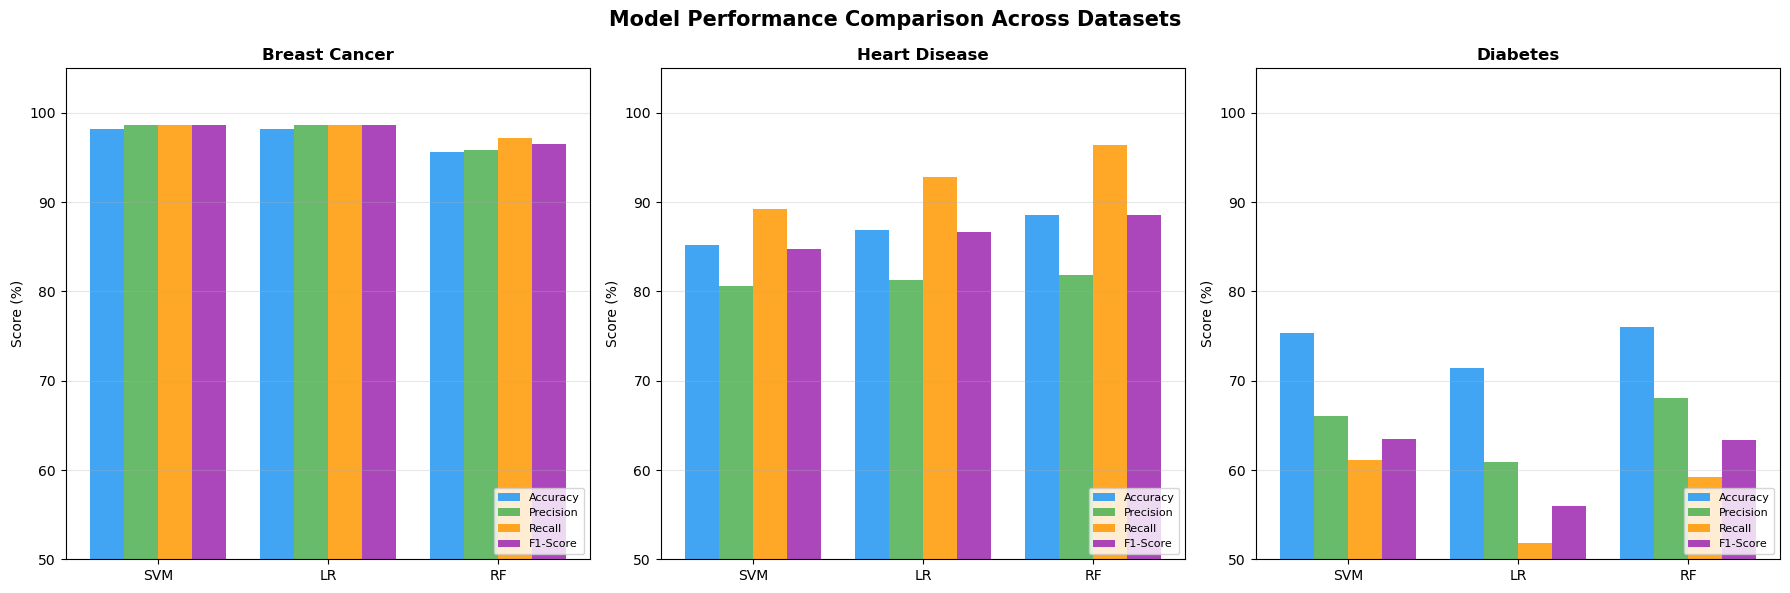

In [23]:
# ─── Grouped Bar Chart: All Metrics per Dataset ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison Across Datasets', fontsize=15, fontweight='bold')

metric = 'F1-Score'  # Primary metric for imbalanced medical data
model_names = list(models.keys())
x = np.arange(len(model_names))
bar_w = 0.2
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax_idx, (ds_name, ax) in enumerate(zip(datasets.keys(), axes)):
    ds_results = results_df[results_df['Dataset'] == ds_name]
    
    for m_idx, (metric_name, color) in enumerate(zip(metric_cols, metric_colors)):
        vals = [ds_results[ds_results['Model'] == m][metric_name].values[0] for m in model_names]
        bars = ax.bar(x + m_idx * bar_w, vals, bar_w, label=metric_name, color=color, alpha=0.85)
    
    ax.set_title(f'{ds_name}', fontsize=12, fontweight='bold')
    ax.set_xticks(x + bar_w * 1.5)
    ax.set_xticklabels(['SVM', 'LR', 'RF'], fontsize=10)
    ax.set_ylim(50, 105)
    ax.set_ylabel('Score (%)')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

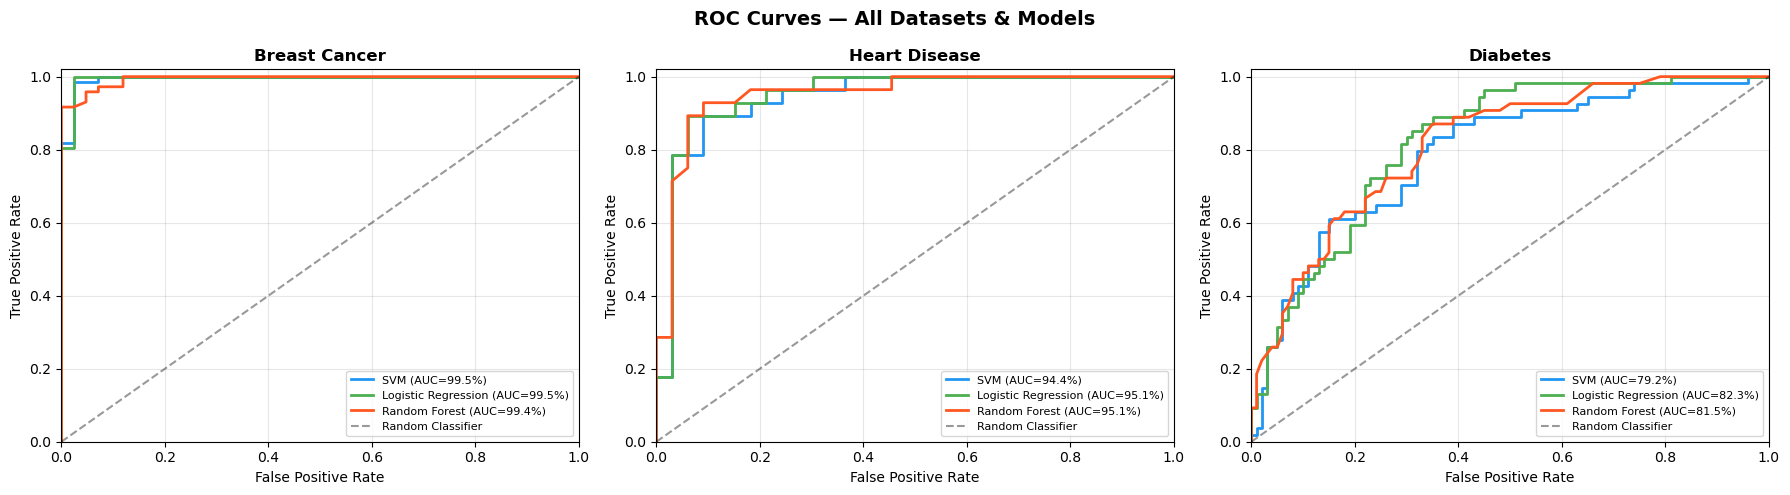

In [24]:
# ─── ROC Curves for All Datasets ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves — All Datasets & Models', fontsize=14, fontweight='bold')
COLORS = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
roc_colors = COLORS

for ax_idx, ds_name in enumerate(datasets.keys()):
    ax = axes[ax_idx]
    ds_results = [r for r in all_results if r['Dataset'] == ds_name]
    
    for i, res in enumerate(ds_results):
        fpr, tpr, _ = roc_curve(res['_y_test'], res['_y_prob'])
        auc = res['ROC-AUC']
        ax.plot(fpr, tpr, color=roc_colors[i], lw=2,
                label=f"{res['Model']} (AUC={auc:.1f}%)")
    
    ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(ds_name, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

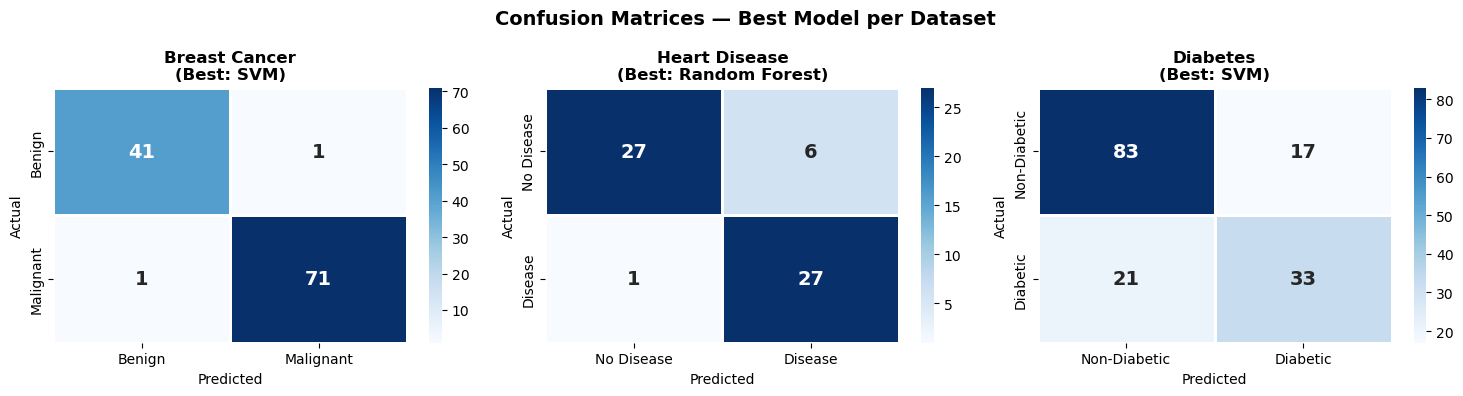

In [25]:
# ─── Confusion Matrices (Best Model per Dataset) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — Best Model per Dataset', fontsize=14, fontweight='bold')

dataset_labels = {
    'Heart Disease': ['No Disease', 'Disease'],
    'Diabetes':      ['Non-Diabetic', 'Diabetic'],
    'Breast Cancer': ['Benign', 'Malignant'],
}

for ax_idx, ds_name in enumerate(datasets.keys()):
    ds_results = [r for r in all_results if r['Dataset'] == ds_name]
    # Pick best model by F1-Score
    best = max(ds_results, key=lambda x: x['F1-Score'])
    
    cm = confusion_matrix(best['_y_test'], best['_y_pred'])
    labels = dataset_labels[ds_name]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[ax_idx], linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[ax_idx].set_title(f'{ds_name}\n(Best: {best["Model"]})', fontweight='bold')
    axes[ax_idx].set_xlabel('Predicted')
    axes[ax_idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [26]:
cv_datasets = {
    'Breast Cancer': (X1, y1),
    'Heart Disease': (X2, y2),
    'Diabetes': (X3, y3)}

# 5-fold Stratified CV

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_results = []

print("="*70)
print("5-Fold Cross Validation Results (F1 Score)")
print("="*70)

for dataset_name, (X, y) in cv_datasets.items():
    print(f"\n{dataset_name}")
    print("-"*50)
    for model_name, model in models.items():
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model)])
        scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=cv,
            scoring='f1',
            n_jobs=1)
        mean_f1 = scores.mean()*100
        std_f1 = scores.std()*100
        cv_results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Mean F1 Score (%)': round(mean_f1, 2),
            'Std (%)': round(std_f1, 2)})
        print(f"{model_name:<20}: {mean_f1:.2f}% ± {std_f1:.2f}%")

cv_df = pd.DataFrame(cv_results)
print("\n")
print(cv_df)

5-Fold Cross Validation Results (F1 Score)

Breast Cancer
--------------------------------------------------
SVM                 : 98.20% ± 1.28%
Logistic Regression : 97.94% ± 1.27%
Random Forest       : 96.51% ± 0.97%

Heart Disease
--------------------------------------------------
SVM                 : 81.53% ± 4.67%
Logistic Regression : 81.26% ± 5.48%
Random Forest       : 82.42% ± 4.98%

Diabetes
--------------------------------------------------
SVM                 : 62.26% ± 1.63%
Logistic Regression : 63.88% ± 1.18%
Random Forest       : 64.41% ± 2.12%


         Dataset                Model  Mean F1 Score (%)  Std (%)
0  Breast Cancer                  SVM              98.20     1.28
1  Breast Cancer  Logistic Regression              97.94     1.27
2  Breast Cancer        Random Forest              96.51     0.97
3  Heart Disease                  SVM              81.53     4.67
4  Heart Disease  Logistic Regression              81.26     5.48
5  Heart Disease        Random Fo

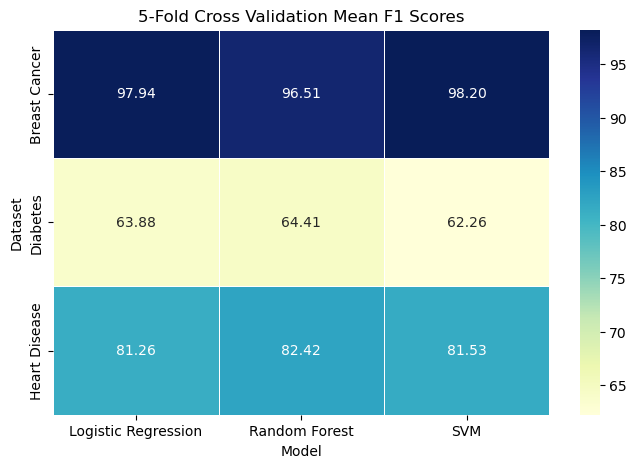

In [27]:
pivot_cv = cv_df.pivot(
    index='Dataset',
    columns='Model',
    values='Mean F1 Score (%)')

plt.figure(figsize=(8,5))
sns.heatmap(
    pivot_cv,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5)

plt.title('5-Fold Cross Validation Mean F1 Scores')
plt.show()

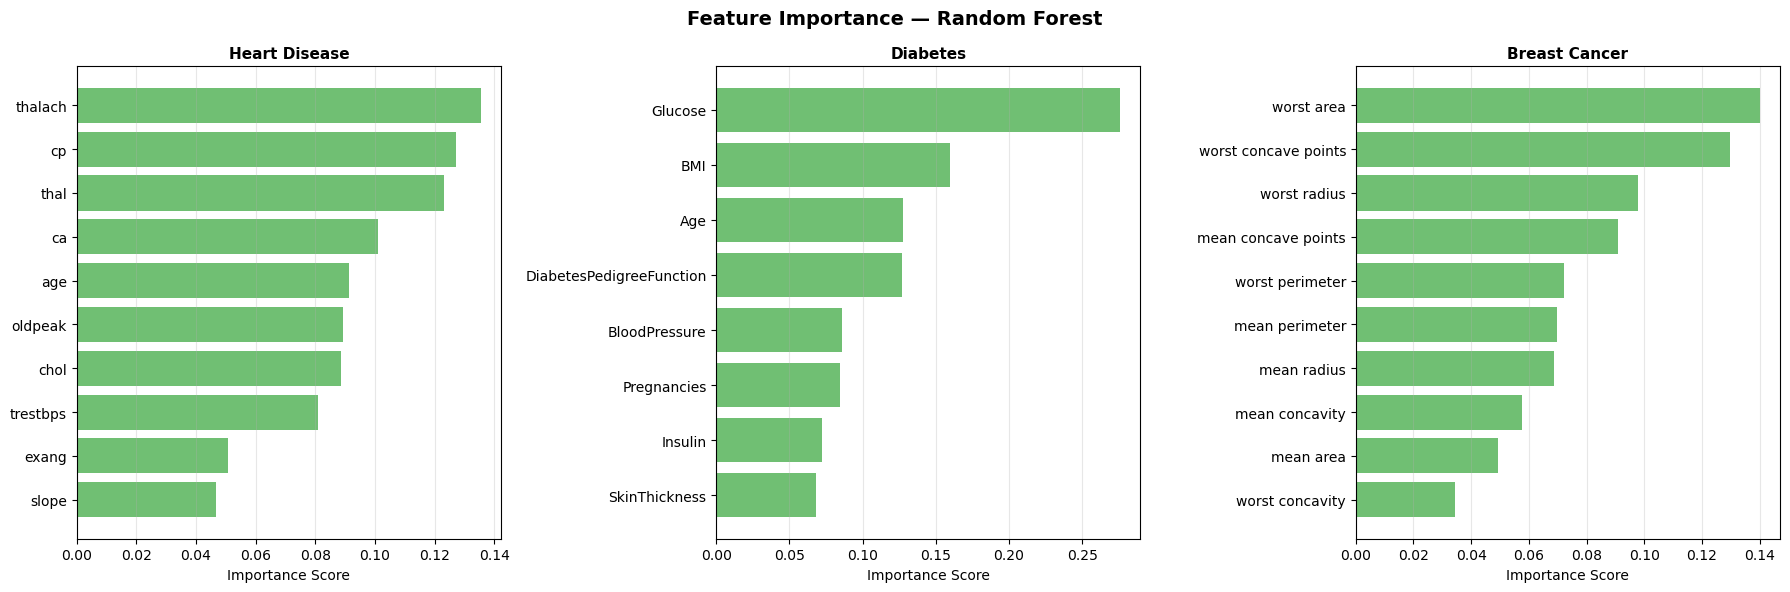

In [28]:
# ─── Feature Importance (Random Forest) ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance — Random Forest', fontsize=14, fontweight='bold')

importance_data = [
    ('Heart Disease', X2_train, y2_train),
    ('Diabetes', X3_train, y3_train),
    ('Breast Cancer', X1_train, y1_train)
]

for idx, (ds_name, X_train, y_train) in enumerate(importance_data):
    ax = axes[idx]
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42)
    rf.fit(X_train, y_train)
    importances = rf.feature_importances_

    feature_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances})

    feature_df = feature_df.sort_values(
        by='Importance',
        ascending=False)

    top_10 = feature_df.head(10)
    ax.barh(
        top_10['Feature'][::-1],
        top_10['Importance'][::-1],
        color='#4CAF50',
        alpha=0.8)

    ax.set_title(ds_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

datasets = {
    'Breast Cancer': (X1_train, X1_test, y1_train, y1_test),
    'Heart Disease': (X2_train, X2_test, y2_train, y2_test),
    'Diabetes': (X3_train, X3_test, y3_train, y3_test)
}

tuned_results = []

best_models = {}

for dataset_name, (X_train, X_test, y_train, y_test) in datasets.items():

    print(f"\nRunning GridSearchCV for {dataset_name}...")

    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=1
    )

    grid.fit(X_train, y_train)

    # Best model
    best_rf = grid.best_estimator_
    best_models[dataset_name] = best_rf

    # Predictions
    y_pred = best_rf.predict(X_test)
    y_prob = best_rf.predict_proba(X_test)[:, 1]

    # Metrics
    tuned_results.append({
        'Dataset': dataset_name,
        'Best Parameters': grid.best_params_,
        'CV F1 Score': round(grid.best_score_, 4),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

    print("Best Parameters:", grid.best_params_)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Results dataframe
tuned_results_df = pd.DataFrame(tuned_results)

print("\nTuned Random Forest Results")
print(tuned_results_df)


Running GridSearchCV for Breast Cancer...
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Test Accuracy: 0.956140350877193

Running GridSearchCV for Heart Disease...
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Test Accuracy: 0.9016393442622951

Running GridSearchCV for Diabetes...
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Test Accuracy: 0.7402597402597403

Tuned Random Forest Results
         Dataset                                    Best Parameters  \
0  Breast Cancer  {'max_depth': 10, 'min_samples_leaf': 4, 'min_...   
1  Heart Disease  {'max_depth': 5, 'min_samples_leaf': 1, 'min_s...   
2       Diabetes  {'max_depth': None, 'min_samples_leaf': 2, 'mi...   

   CV F1 Score  Accuracy  Precision  Recall  F1 Score  ROC-AUC  
0       0.9685    0.9561     0.9589  0.9722    0.9655   0.9931  
1       0.8106    0.

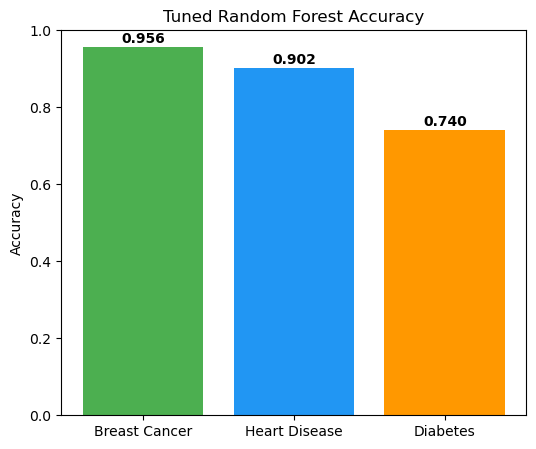

In [31]:
plt.figure(figsize=(6,5))
plt.bar(
    tuned_results_df['Dataset'],
    tuned_results_df['Accuracy'],
    color=['#4CAF50', '#2196F3', '#FF9800'])

plt.title('Tuned Random Forest Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0,1)

for i, v in enumerate(tuned_results_df['Accuracy']):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()